# Numerical Integration: Trapezoid Rule, Simpson Rule and Planck's Law

**Author:** Alberto Reyes Castro  
**Original context:** Computational Physics coursework, BSc Physics  
**Public portfolio version:** English translation, cleaned formatting and reproducible code.

This notebook is a faithful public version of the original numerical-integration coursework. It implements the composite trapezoid rule and the composite Simpson 1/3 rule, calculates error bounds, and applies numerical integration to a physical example based on Planck's law.

## Coursework Task

Implement at least two numerical integration methods studied in class and analyse the influence of the number of intervals on the error.

The two methods used here are:

- Composite trapezoid rule
- Composite Simpson 1/3 rule

Both methods are derived from Newton-Cotes formulas.

## Theoretical Background

The composite trapezoid rule is:

$$
I = \int_a^b f(x)\,dx
\approx
\frac{h}{2}
\left[
f(a)+f(b)+2\sum_{i=1}^{n-1}f(a+ih)
\right]
$$

where $h=(b-a)/n$.

For $n=1$, this reduces to the simple trapezoid rule:

$$
I = \frac{b-a}{2}\left[f(a)+f(b)\right]
$$

The composite Simpson 1/3 rule is:

$$
I =
\int_a^b f(x)\,dx
\approx
\frac{h}{3}
\left[
f(a)
+4\sum_{i=1}^{n/2}f(x_{2i-1})
+2\sum_{i=1}^{n/2-1}f(x_{2i})
+f(b)
\right]
$$

Simpson's 1/3 rule approximates the function using second-order polynomials. It is generally more accurate than the trapezoid rule for smooth functions, but it requires an even number of subintervals.

## Error Bounds

The error formula for the trapezoid rule is:

$$
E_n(f) =
-\frac{(b-a)^3}{12n^2} f''(\xi)
$$

Therefore, an upper bound is:

$$
|E_n(f)| \leq
\frac{|b-a|^3}{12n^2}
\max_{x\in[a,b]} |f''(x)|
$$

For Simpson's 1/3 rule:

$$
E_n(f) =
-\frac{(b-a)h^4}{180}f^{(4)}(\xi)
$$

with the bound:

$$
|E_n(f)| \leq
\frac{|b-a|h^4}{180}
\max_{x\in[a,b]} |f^{(4)}(x)|
$$

The absolute error is the difference between the reference integral and the numerical approximation. The relative error is the absolute error divided by the reference value.

## Exercise 2.1: Composite Trapezoid Rule

We first solve the integral:

$$
\int_{-1}^{1}
\frac{e^{-x^2/2}}{\sqrt{2\pi}}\,dx
$$

using the composite trapezoid rule. The result is compared with a reference value computed using SciPy.

In [2]:
import math
import sys
import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.integrate import quad

x = sp.Symbol("x")

f_trap_symbolic = sp.exp(-x**2 / 2) / sp.sqrt(2 * sp.pi)
f_trap_numeric = sp.lambdify(x, f_trap_symbolic, "numpy")

a = -1
b = 1
n = 2

if n == 0:
    raise ValueError("n cannot be zero. It must be a positive natural number.")

reference_trap, _ = quad(f_trap_numeric, a, b)

def composite_trapezoid(function, a, b, n):
    h = (b - a) / n
    integral = 0.5 * (function(a) + function(b))

    for i in range(1, n):
        x_i = a + i * h
        integral += function(x_i)

    integral *= h
    return integral

trapezoid_value = composite_trapezoid(f_trap_numeric, a, b, n)

def derivative_bound(symbolic_function, variable, derivative_order, a, b, samples=250_000):
    derivative = sp.diff(symbolic_function, variable, derivative_order)
    derivative_function = sp.lambdify(variable, derivative, "numpy")

    x_values = np.linspace(a, b, samples)
    y_values = np.abs(derivative_function(x_values))
    y_values = np.nan_to_num(y_values, nan=0.0, posinf=0.0, neginf=0.0)

    max_index = int(np.argmax(y_values))
    return float(y_values[max_index]), float(x_values[max_index])

max_second_derivative, x_max_second = derivative_bound(f_trap_symbolic, x, 2, a, b)

error_bound_trap = abs(((b - a) ** 3) / (12 * n**2) * max_second_derivative)
absolute_error_trap = abs(reference_trap - trapezoid_value)
relative_error_trap = absolute_error_trap / abs(reference_trap)

trap_results = pd.DataFrame(
    [
        {
            "method": "Composite trapezoid",
            "a": a,
            "b": b,
            "n": n,
            "approximation": trapezoid_value,
            "reference_scipy_quad": reference_trap,
            "absolute_error": absolute_error_trap,
            "relative_error": relative_error_trap,
            "error_bound": error_bound_trap,
        }
    ]
)

trap_results

,method,a,b,n,approximation,reference_scipy_quad,absolute_error,relative_error,error_bound
0,Composite trapezoid,-1,1,2,0.640913,0.682689,0.041776,0.061194,0.06649


The absolute error is within the theoretical error bound.

The error bound was computed using the maximum absolute value of the second derivative over the integration interval. This auxiliary derivative value is used internally for the bound calculation, but it is not shown in the main results table to keep the output clean.

The accuracy depends on the number of subintervals `n`: increasing `n` decreases the step size and usually improves the approximation.

## Exercise 2.2: Composite Simpson 1/3 Rule

We now solve the integral:

$$
\int_0^3
\frac{e^x\sin(x)}{1+x^2}\,dx
$$

using the composite Simpson 1/3 rule. The result is again compared with SciPy.

In [3]:
f_simp_symbolic = sp.exp(x) * sp.sin(x) / (1 + x**2)
f_simp_numeric = sp.lambdify(x, f_simp_symbolic, "numpy")

a = 0
b = 3
n = 4

if n in [0, 1]:
    raise ValueError("Simpson's rule requires at least two subintervals.")

if n % 2 != 0:
    raise ValueError("Composite Simpson's 1/3 rule requires an even number of subintervals.")

reference_simp, _ = quad(f_simp_numeric, a, b)

def composite_simpson_13(function, a, b, n):
    h = (b - a) / n
    x_values = [a + i * h for i in range(n + 1)]
    f_values = [function(x_i) for x_i in x_values]

    integral = f_values[0] + f_values[-1]

    for i in range(1, n):
        if i % 2 == 0:
            integral += 2 * f_values[i]
        else:
            integral += 4 * f_values[i]

    integral *= h / 3
    return integral

simpson_value = composite_simpson_13(f_simp_numeric, a, b, n)

h = (b - a) / n
max_fourth_derivative, x_max_fourth = derivative_bound(f_simp_symbolic, x, 4, a, b)

error_bound_simp = abs(((b - a) * h**4) / 180 * max_fourth_derivative)
absolute_error_simp = abs(reference_simp - simpson_value)
relative_error_simp = absolute_error_simp / abs(reference_simp)

simpson_results = pd.DataFrame(
    [
        {
            "method": "Composite Simpson 1/3",
            "a": a,
            "b": b,
            "n": n,
            "approximation": simpson_value,
            "reference_scipy_quad": reference_simp,
            "absolute_error": absolute_error_simp,
            "relative_error": relative_error_simp,
            "error_bound": error_bound_simp,
        }
    ]
)

simpson_results

,method,a,b,n,approximation,reference_scipy_quad,absolute_error,relative_error,error_bound
0,Composite Simpson 1/3,0,3,4,2.899839,2.881637,0.018201,0.006316,0.126563


Simpson's 1/3 rule converges faster than the trapezoid rule for smooth functions because its error depends on a higher power of the step size.

The Simpson error bound was computed using the maximum absolute value of the fourth derivative over the integration interval. As with the trapezoid case, this derivative value is used internally for the theoretical bound but is not displayed in the main results table.

In general:

- The trapezoid-rule error decreases proportionally to `1/n²`.
- The Simpson-rule error decreases proportionally to `1/n⁴` for sufficiently smooth functions.

Increasing the number of intervals improves accuracy, but it also increases the computational cost.

## Influence of the Number of Intervals

To make the influence of $n$ visible, we repeat the trapezoid and Simpson calculations for several values of $n$.

In [4]:
n_values = [2, 4, 8, 16, 32, 64, 128]

convergence_rows = []

trap_integral_label = "∫[-1,1] exp(-x²/2) / sqrt(2π) dx"
simp_integral_label = "∫[0,3] exp(x) sin(x) / (1 + x²) dx"

for n_value in n_values:
    trap_value = composite_trapezoid(f_trap_numeric, -1, 1, n_value)

    convergence_rows.append(
        {
            "integral": trap_integral_label,
            "method": "trapezoid",
            "n": n_value,
            "absolute_error": abs(reference_trap - trap_value),
        }
    )

    simp_value = composite_simpson_13(f_simp_numeric, 0, 3, n_value)

    convergence_rows.append(
        {
            "integral": simp_integral_label,
            "method": "Simpson 1/3",
            "n": n_value,
            "absolute_error": abs(reference_simp - simp_value),
        }
    )

convergence_df = pd.DataFrame(convergence_rows)
convergence_df

,integral,method,n,absolute_error
0,"∫[-1,1] exp(-x²/2) / sqrt(2π) dx",trapezoid,2,4.177649e-02
1,"∫[0,3] exp(x) sin(x) / (1 + x²) dx",Simpson 1/3,2,1.114006e-02
2,"∫[-1,1] exp(-x²/2) / sqrt(2π) dx",trapezoid,4,1.016766e-02
3,"∫[0,3] exp(x) sin(x) / (1 + x²) dx",Simpson 1/3,4,1.820139e-02
4,"∫[-1,1] exp(-x²/2) / sqrt(2π) dx",trapezoid,8,2.525803e-03
5,"∫[0,3] exp(x) sin(x) / (1 + x²) dx",Simpson 1/3,8,8.566932e-04
6,"∫[-1,1] exp(-x²/2) / sqrt(2π) dx",trapezoid,16,6.304607e-04
7,"∫[0,3] exp(x) sin(x) / (1 + x²) dx",Simpson 1/3,16,2.869009e-05
8,"∫[-1,1] exp(-x²/2) / sqrt(2π) dx",trapezoid,32,1.575535e-04
9,"∫[0,3] exp(x) sin(x) / (1 + x²) dx",Simpson 1/3,32,1.661487e-06


The table above shows an additional convergence check for the two numerical-integration exercises.

The first integral,

$$
\int_{-1}^{1} \frac{e^{-x^2/2}}{\sqrt{2\pi}}\,dx,
$$

is approximated using the composite trapezoid rule.

The second integral,

$$
\int_{0}^{3} \frac{e^x\sin(x)}{1+x^2}\,dx,
$$

is approximated using Simpson's 1/3 rule.

For each case, the table evaluates the absolute error for different values of `n`. Overall, increasing the number of subintervals tends to reduce the error, although the decrease is not necessarily perfectly monotonic for every small value of `n`.

The results should not be interpreted as a direct comparison between the trapezoid and Simpson methods, since they are applied to different functions and intervals. Instead, the table illustrates the convergence behaviour of each method in its corresponding exercise.

## Exercise 3: Physical Case of Interest — Planck's Law

As an additional case, the original coursework implemented a program to estimate the solar irradiance reaching Earth using **Planck's law for a black body**.

Planck's spectral radiance expression is:

$$
I_s(\lambda, T)
=
\frac{2\pi h c^2}{\lambda^5}
\frac{1}{e^{\frac{hc}{\lambda kT}}-1}
$$

where:

- $h = 6.62607015\times10^{-34}\,\text{J s}$ is Planck's constant,
- $c = 3\times10^8\,\text{m/s}$ is the speed of light,
- $k = 1.380649\times10^{-23}\,\text{J/K}$ is Boltzmann's constant,
- $\lambda$ is the wavelength,
- $T$ is the temperature in Kelvin.

The total emitted intensity over a wavelength interval is:

$$
I = \int_{\lambda=a}^{b} I_s(\lambda,T)\,d\lambda
$$

The irradiance reaching Earth is estimated using the geometric dilution factor:

$$
I_t =
\frac{R_{\odot}^{2}}{D_{\text{Earth-Sun}}^{2}} I
$$

This simplified calculation ignores atmospheric and geographical effects.

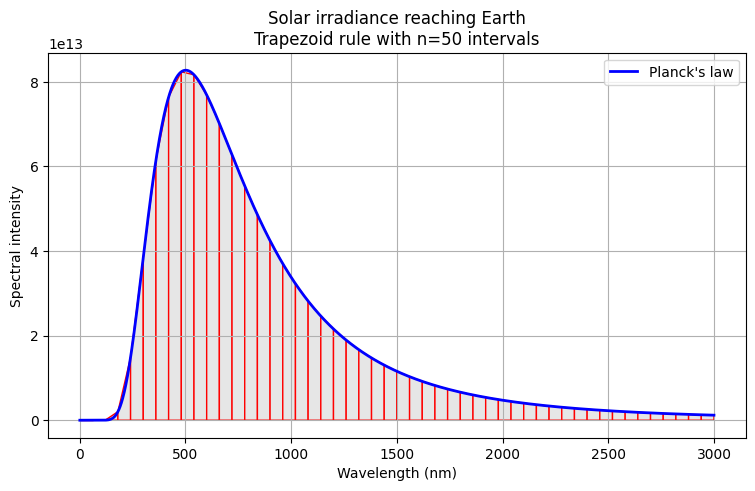

,method,solar_surface_intensity_W_m2,earth_irradiance_W_m2
0,Trapezoid rule over finite spectral range,6.177118e+07,1338.344375
1,SciPy quad over finite spectral range,6.177158e+07,1338.353015
2,Stefan-Boltzmann full-spectrum check,6.319653e+07,1369.226207


I using the trapezoid rule: I = 61771178.05 W/m²
I using SciPy quad: I = 61771576.81 W/m²
I_t using the trapezoid rule: I_t = 1338.34 W/m²
I_t using SciPy quad: I_t = 1338.35 W/m²

Finally, a comparison is made with the Stefan-Boltzmann law:
Solar intensity using Stefan-Boltzmann: I = 63196526.55 W/m²
I_t using Stefan-Boltzmann: I_t = 1369.23 W/m²

Since the selected wavelength range covers a large part of the solar spectrum, the Stefan-Boltzmann result provides a useful full-spectrum consistency check.
Increasing the number of intervals n generally improves the trapezoid-rule approximation.


In [5]:
# Import the required modules
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.integrate import quad
import pandas as pd

# Planck's law for a black body
def planck_law(wavelength, temperature):
    h_planck = 6.62607015e-34
    c_light = 3e8
    k_boltzmann = 1.380649e-23

    scalar_input = np.isscalar(wavelength)
    wavelength_array = np.atleast_1d(np.asarray(wavelength, dtype=float))

    exponent = (h_planck * c_light) / (wavelength_array * k_boltzmann * temperature)
    prefactor = (2 * np.pi * h_planck * c_light**2) / wavelength_array**5

    # Stable evaluation to avoid overflow warnings for very short wavelengths.
    intensity = np.zeros_like(wavelength_array, dtype=float)
    safe_mask = exponent <= 700
    intensity[safe_mask] = prefactor[safe_mask] / np.expm1(exponent[safe_mask])

    if scalar_input:
        return float(intensity[0])

    return intensity


# Parameters
temperature = 5778
wavelength_min = 1e-9
wavelength_max = 3e-6
n = 50

a = wavelength_min
b = wavelength_max
h = (b - a) / n


# Composite trapezoid rule
def trapezoid_rule_with_temperature(function, a, b, n, temperature):
    h = (b - a) / n
    integral = 0.5 * (function(a, temperature) + function(b, temperature))

    for i in range(1, n):
        x_i = a + i * h
        integral += function(x_i, temperature)

    integral *= h
    return integral


# Integral using the trapezoid rule
planck_trapezoid = trapezoid_rule_with_temperature(
    planck_law,
    a,
    b,
    n,
    temperature,
)

# Solar irradiance reaching Earth using the geometric dilution factor
solar_radius = 6.96342e8
earth_sun_distance = 1.496e11

earth_irradiance_trapezoid = (
    planck_trapezoid * solar_radius**2 / earth_sun_distance**2
)

# Reference integral using SciPy
planck_reference, _ = quad(
    planck_law,
    wavelength_min,
    wavelength_max,
    args=(temperature,),
)

earth_irradiance_reference = (
    planck_reference * solar_radius**2 / earth_sun_distance**2
)

# Plot Planck's law and the trapezoids
wavelength_range = np.linspace(wavelength_min, wavelength_max, 2000)
spectral_intensity = planck_law(wavelength_range, temperature)

plt.figure(figsize=(9, 5))
plt.plot(
    wavelength_range * 1e9,
    spectral_intensity,
    "b",
    linewidth=2,
    label="Planck's law",
)

# Draw the trapezoids
for i in range(n):
    x1 = wavelength_min + i * h
    x2 = wavelength_min + (i + 1) * h

    y1 = planck_law(x1, temperature)
    y2 = planck_law(x2, temperature)

    vertices = [
        (x1 * 1e9, 0),
        (x1 * 1e9, y1),
        (x2 * 1e9, y2),
        (x2 * 1e9, 0),
    ]

    polygon = patches.Polygon(
        vertices,
        edgecolor="r",
        facecolor="0.9",
        linewidth=1,
    )

    plt.gca().add_patch(polygon)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Spectral intensity")
plt.title(
    f"Solar irradiance reaching Earth\n"
    f"Trapezoid rule with n={n} intervals"
)
plt.legend()
plt.grid(True)
plt.show()


# Stefan-Boltzmann full-spectrum consistency check
stefan_boltzmann_intensity = 5.670e-8 * temperature**4

earth_irradiance_stefan = (
    stefan_boltzmann_intensity * solar_radius**2 / earth_sun_distance**2
)

# Summary table
planck_summary = pd.DataFrame(
    [
        {
            "method": "Trapezoid rule over finite spectral range",
            "solar_surface_intensity_W_m2": planck_trapezoid,
            "earth_irradiance_W_m2": earth_irradiance_trapezoid,
        },
        {
            "method": "SciPy quad over finite spectral range",
            "solar_surface_intensity_W_m2": planck_reference,
            "earth_irradiance_W_m2": earth_irradiance_reference,
        },
        {
            "method": "Stefan-Boltzmann full-spectrum check",
            "solar_surface_intensity_W_m2": stefan_boltzmann_intensity,
            "earth_irradiance_W_m2": earth_irradiance_stefan,
        },
    ]
)

display(planck_summary)

print(f"I using the trapezoid rule: I = {planck_trapezoid:.2f} W/m²")
print(f"I using SciPy quad: I = {planck_reference:.2f} W/m²")
print(f"I_t using the trapezoid rule: I_t = {earth_irradiance_trapezoid:.2f} W/m²")
print(f"I_t using SciPy quad: I_t = {earth_irradiance_reference:.2f} W/m²")
print()
print("Finally, a comparison is made with the Stefan-Boltzmann law:")
print(f"Solar intensity using Stefan-Boltzmann: I = {stefan_boltzmann_intensity:.2f} W/m²")
print(f"I_t using Stefan-Boltzmann: I_t = {earth_irradiance_stefan:.2f} W/m²")
print()
print(
    "Since the selected wavelength range covers a large part of the solar spectrum, "
    "the Stefan-Boltzmann result provides a useful full-spectrum consistency check."
)
print(
    "Increasing the number of intervals n generally improves the trapezoid-rule approximation."
)

The plot preserves the original coursework idea: Planck's law is represented as a blue curve and the composite trapezoid approximation is shown using red-edged trapezoids.

The first row of the table gives the result obtained with the composite trapezoid rule over the finite wavelength interval from `1e-9 m` to `3e-6 m`. The second row gives the SciPy `quad` reference result over the same interval. The two values are close, which validates the trapezoid-rule implementation for this case.

The third row uses the Stefan-Boltzmann law as a full-spectrum consistency check. This value is slightly higher because Stefan-Boltzmann integrates the black-body emission over all wavelengths, while the numerical integration above only covers a finite spectral range.

This simplified model does not include atmospheric absorption, local geography or deviations of the real solar spectrum from an ideal black body.